In [1]:
import os
import re
import sys
from pathlib import Path
import torch
import pandas as pd
from typing import List, Dict, Optional
from huggingface_hub import HfApi, snapshot_download
from transformers import AutoTokenizer, AutoModelForCausalLM

# =============== CONFIG ===============
DATA_DIR = r"D:\Now\cookie_control_dementia"
MODEL_NAME = "Qwen/Qwen3-4B"
HF_TOKEN = os.environ.get("HF_TOKEN")
OUTPUT_CSV = r"D:\Now\qwen3_4B_zeroshot_binaryclass.csv"

GEN_MAX_NEW_TOKENS = 512
GEN_TEMPERATURE = 0.3
GEN_TOP_P = 0.9

# =============== HF SANITY CHECK ===============
def hf_sanity_check(model_name: str, token: Optional[str] = None) -> bool:
    api = HfApi()
    try:
        info = api.model_info(model_name, token=token)
        print(f"✅ HF CHECK OK: {info.modelId} (private={info.private})")
        return True
    except Exception as e:
        print(f"❌ HF CHECK ERROR: {type(e).__name__}: {e}", file=sys.stderr)
        return False

# =============== TOKENIZER / MODEL LOADERS ===============
def load_qwen_tokenizer(model_name: str, hf_token: Optional[str] = None):
    """Load Qwen tokenizer with fallback to local cache."""
    kwargs = {"trust_remote_code": True}
    if hf_token:
        kwargs["token"] = hf_token
    try:
        tok = AutoTokenizer.from_pretrained(model_name, **kwargs)
        print(f"✅ Tokenizer loaded: {model_name}")
    except Exception as e_remote:
        print(f"[Tokenizer] Remote load failed: {type(e_remote).__name__}: {e_remote}", file=sys.stderr)
        print(f"[Tokenizer] Attempting local cache...")
        local_dir = snapshot_download(repo_id=model_name, token=hf_token)
        tok = AutoTokenizer.from_pretrained(local_dir, trust_remote_code=True, local_files_only=True)
        print(f"✅ Tokenizer loaded from local cache")
    
    if not getattr(tok, "chat_template", None):
        tok.chat_template = (
            "{% for m in messages %}"
            "{{'<|im_start|>' + m['role'] + '\\n' + m['content'] + '<|im_end|>\\n'}}"
            "{% endfor %}"
            "<|im_start|>assistant\n"
        )
    return tok

def load_qwen_model(model_name: str, hf_token: Optional[str] = None, torch_dtype=torch.float16):
    """Load Qwen model with fallback to local cache."""
    kwargs = {"trust_remote_code": True, "torch_dtype": torch_dtype, "device_map": "auto"}
    if hf_token:
        kwargs["token"] = hf_token
    try:
        model = AutoModelForCausalLM.from_pretrained(model_name, **kwargs)
        print(f"✅ Model loaded: {model_name}")
        return model
    except Exception as e_remote:
        print(f"[Model] Remote load failed: {type(e_remote).__name__}: {e_remote}", file=sys.stderr)
        print(f"[Model] Attempting local cache...")
        local_dir = snapshot_download(repo_id=model_name, token=hf_token)
        model = AutoModelForCausalLM.from_pretrained(
            local_dir, 
            trust_remote_code=True, 
            local_files_only=True, 
            torch_dtype=torch_dtype, 
            device_map="auto"
        )
        print(f"✅ Model loaded from local cache")
        return model

# =============== PROMPT / PARSING ===============
def extract_patient_info(filename: str):
    """Extract patient ID from filename (first 3 digits)."""
    match = re.match(r'(\d{3})', filename)
    return match.group(1) if match else None

def create_zeroshot_prompt(filename: str, transcript: str) -> str:
    """Create zero-shot prompt for dementia diagnosis."""
    return f"""You are an expert neuropsychologist specializing in dementia assessment. Analyze the following Cookie Theft picture description transcript.

**File:** {filename}

**Transcript:**
{transcript}

**Task:**
Based on this transcript, ALWAYS predict all three values:

1. **Diagnosis Label**: Choose ONE from: ProbableAD or Control
2. **MMSE Score**: Predict a score between 0-30 (required for ALL cases)
3. **Confidence**: Rate as Low, Medium, or High

**REQUIRED Response Format (must include all three fields):**
Label: [ProbableAD/Control]
MMSE: [0-30]
Confidence: [Low/Medium/High]

You MUST output all three lines above."""

def parse_llm_response(response: str) -> Dict:
    """Parse LLM response to extract label, MMSE, and confidence with STRICT validation."""
    # Strip Qwen3 thinking tags if present
    clean_response = re.sub(r'<think>.*?</think>', '', response, flags=re.DOTALL).strip()
    if not clean_response:
        clean_response = response
    
    # Extract fields
    label_match = re.search(r'Label:\s*(\w+)', clean_response, re.IGNORECASE)
    mmse_match = re.search(r'MMSE:\s*(\d+)', clean_response, re.IGNORECASE)
    conf_match = re.search(r'Confidence:\s*(\w+)', clean_response, re.IGNORECASE)
    
    # STRICT LABEL VALIDATION - only Control or ProbableAD accepted
    label = 'Unknown'
    if label_match:
        candidate = label_match.group(1).strip().lower()
        if candidate == 'control':
            label = 'Control'
        elif candidate == 'probablead':
            label = 'ProbableAD'
    else:
        # Fallback: search for exact word boundary matches
        if re.search(r'\bcontrol\b', clean_response, re.IGNORECASE):
            label = 'Control'
        elif re.search(r'\bprobablead\b', clean_response, re.IGNORECASE):
            label = 'ProbableAD'
    
    # STRICT MMSE VALIDATION - must be 0-30 integer
    mmse_value = -1
    if mmse_match:
        try:
            val = int(mmse_match.group(1))
            if 0 <= val <= 30:
                mmse_value = val
        except (ValueError, TypeError):
            pass
    
    # FALLBACK: If MMSE missing, estimate based on label
    if mmse_value == -1:
        # Reasonable defaults if model didn't provide MMSE
        if label == 'ProbableAD':
            mmse_value = 20  # Typical AD MMSE
        elif label == 'Control':
            mmse_value = 28  # Typical control MMSE
    
    # STRICT CONFIDENCE VALIDATION - only Low/Medium/High accepted
    confidence = 'Unknown'
    if conf_match:
        candidate = conf_match.group(1).strip().lower()
        if candidate in ['low', 'medium', 'high']:
            confidence = candidate.capitalize()
    
    return {
        'label': label,
        'mmse': mmse_value,
        'confidence': confidence,
        'raw': response
    }

# =============== CHAT RENDER / GENERATION ===============
def render_messages_to_text(messages: List[Dict], tokenizer) -> str:
    """Render messages to text format for model input."""
    if hasattr(tokenizer, "apply_chat_template"):
        try:
            return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            pass
    
    # Fallback: manual formatting
    out = ""
    for m in messages:
        role = m.get("role", "")
        content = m.get("content", "")
        out += f"<|im_start|>{role}\n{content}<|im_end|>\n"
    out += "<|im_start|>assistant\n"
    return out

def generate_from_model(text: str, tokenizer, model) -> str:
    """Generate text from model given prompt."""
    model_inputs = tokenizer(
        [text], 
        return_tensors="pt", 
        truncation=True, 
        padding=True
    ).to(next(model.parameters()).device)
    
    generated = model.generate(
        input_ids=model_inputs.input_ids,
        attention_mask=model_inputs.attention_mask,
        max_new_tokens=GEN_MAX_NEW_TOKENS,
        temperature=GEN_TEMPERATURE,
        top_p=GEN_TOP_P,
        do_sample=True,
        pad_token_id=(tokenizer.pad_token_id if tokenizer.pad_token_id else tokenizer.eos_token_id)
    )
    
    for in_ids, out_ids in zip(model_inputs.input_ids, generated):
        new_ids = out_ids[len(in_ids):]
        return tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    return ""

# =============== ZERO-SHOT PREDICTION ===============
def predict_visit_zeroshot(filename: str, transcript: str, tokenizer, model) -> str:
    """Make zero-shot prediction without any examples."""
    prompt = create_zeroshot_prompt(filename, transcript)
    
    messages = [
        {"role": "system", "content": "You are an expert neuropsychologist diagnosing dementia from speech. Respond directly with Label, MMSE, and Confidence only."},
        {"role": "user", "content": prompt}
    ]
    
    text = render_messages_to_text(messages, tokenizer)
    return generate_from_model(text, tokenizer, model)

# =============== MAIN EXECUTION ===============
def main():
    """Main execution: load model, process transcripts, save predictions."""
    
    print("=" * 70)
    print("CHECKING MODEL ON HUGGINGFACE...")
    print("=" * 70)
    hf_sanity_check(MODEL_NAME, HF_TOKEN)
    
    print("\n" + "=" * 70)
    print("LOADING TOKENIZER AND MODEL...")
    print("=" * 70)
    tokenizer = load_qwen_tokenizer(MODEL_NAME, hf_token=HF_TOKEN)
    
    model = load_qwen_model(
        MODEL_NAME, 
        hf_token=HF_TOKEN,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
    )
    
    if model:
        print(f"   Device: {next(model.parameters()).device}")
    
    # Get transcript files
    files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith(".txt"))
    print(f"\n✅ Found {len(files)} transcript files in {DATA_DIR}")
    
    # Process each transcript
    print("\n" + "=" * 70)
    print("PROCESSING TRANSCRIPTS (ZERO-SHOT)...")
    print("=" * 70)
    
    results = []
    for i, filename in enumerate(files, 1):
        pid = extract_patient_info(filename)
        path = Path(DATA_DIR) / filename
        
        print(f"\n[{i:3d}/{len(files)}] Processing {filename} (Patient ID: {pid})")
        
        try:
            with open(path, "r", encoding="utf-8") as f:
                transcript = f.read().strip()
            
            if not transcript:
                raise ValueError("Empty transcript")
            
            # Make prediction (zero-shot)
            response = predict_visit_zeroshot(filename, transcript, tokenizer, model)
            prediction = parse_llm_response(response)
            
            print(f"           → Label: {prediction['label']:12s} | MMSE: {prediction['mmse']:3d} | Confidence: {prediction['confidence']}")
            
            # Remove .txt from filename for 'id'
            file_id = re.sub(r'\.txt$', '', filename)
            
            results.append({
                "id": file_id,
                "confidence": prediction["confidence"],
                "mmse": prediction["mmse"],
                "dx": prediction["label"]
            })
            
        except Exception as e:
            print(f"           ⚠️  ERROR: {e}", file=sys.stderr)
            file_id = re.sub(r'\.txt$', '', filename)
            results.append({
                "id": file_id,
                "confidence": "N/A",
                "mmse": -1,
                "dx": "Error"
            })
    
    # Save results
    print("\n" + "=" * 70)
    print("SAVING RESULTS...")
    print("=" * 70)
    df = pd.DataFrame(results, columns=["id", "confidence", "mmse", "dx"])
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"✅ Results saved to: {OUTPUT_CSV}")
    
    # Display sample
    print("\n" + "=" * 70)
    print("SAMPLE PREDICTIONS (first 10 rows):")
    print("=" * 70)
    print(df.head(10).to_string(index=False))
    
    print(f"\n✅ Processing complete! Total: {len(results)} predictions")
    
    return df

if __name__ == "__main__":
    df_results = main()

C:\Users\T2510627\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CHECKING MODEL ON HUGGINGFACE...
✅ HF CHECK OK: Qwen/Qwen3-4B (private=False)

LOADING TOKENIZER AND MODEL...
✅ Tokenizer loaded: Qwen/Qwen3-4B


`torch_dtype` is deprecated! Use `dtype` instead!
C:\Users\T2510627\AppData\Roaming\Python\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
Loading checkpoint shards: 100%|██████████| 3/3 [00:03<00:00,  1.03s/it]


✅ Model loaded: Qwen/Qwen3-4B
   Device: cuda:0

✅ Found 552 transcript files in D:\Now\cookie_control_dementia

PROCESSING TRANSCRIPTS (ZERO-SHOT)...

[  1/552] Processing 001-0.txt (Patient ID: 001)
           → Label: Control      | MMSE:  28 | Confidence: Unknown

[  2/552] Processing 001-2.txt (Patient ID: 001)
           → Label: ProbableAD   | MMSE:  20 | Confidence: High

[  3/552] Processing 002-0.txt (Patient ID: 002)
           → Label: Control      | MMSE:  28 | Confidence: Unknown

[  4/552] Processing 002-1.txt (Patient ID: 002)
           → Label: Control      | MMSE:  28 | Confidence: Unknown

[  5/552] Processing 002-2.txt (Patient ID: 002)
           → Label: ProbableAD   | MMSE:  22 | Confidence: Medium

[  6/552] Processing 002-3.txt (Patient ID: 002)
           → Label: Control      | MMSE:  28 | Confidence: Unknown

[  7/552] Processing 003-0.txt (Patient ID: 003)
           → Label: ProbableAD   | MMSE:  22 | Confidence: Medium

[  8/552] Processing 005-0.txt (Pa

Loading CSVs...
Loaded actual: D:\Now\2_classes.csv
Loaded predictions: D:\Now\qwen3_4B_zeroshot_binaryclass.csv
Using (actual) mmse column: 'mmse'  label column: 'dx'
Using (pred)   mmse column: 'mmse'  label column: 'dx'
Merged 498 rows on 'id'.

📊 Evaluation Results (Qwen3-4B Zero-Shot)
Samples evaluated: 498
Label Accuracy: 44.58% (222/498)
MMSE Mean Absolute Error (MAE): 9.904
MMSE Pearson correlation: -0.053

Per-class precision/recall/f1:
     label  precision   recall       f1  support
   control   0.532468 0.506173 0.518987      243
probablead   0.607362 0.388235 0.473684      255
   unknown   0.000000 0.000000 0.000000        0

Saved merged evaluation CSV: D:\Now\qwen3_4B_zeroshot_binaryclass_vs_actual_evaluation.csv


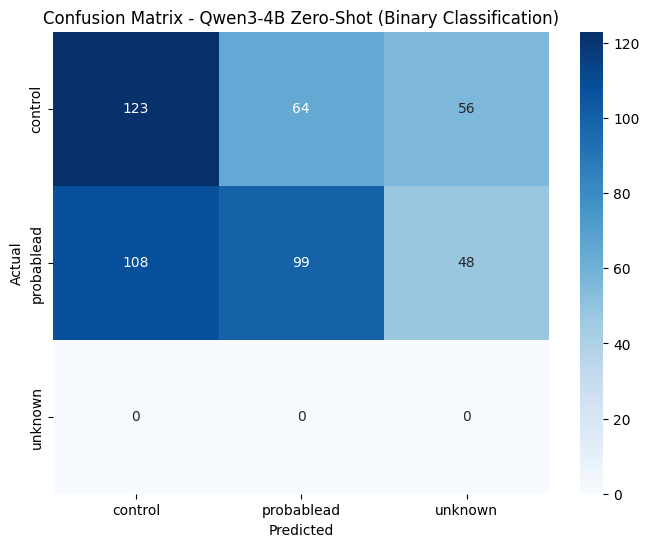

Saved confusion matrix to: D:\Now\qwen3_4B_zeroshot_binaryclass_confusion_matrix.png


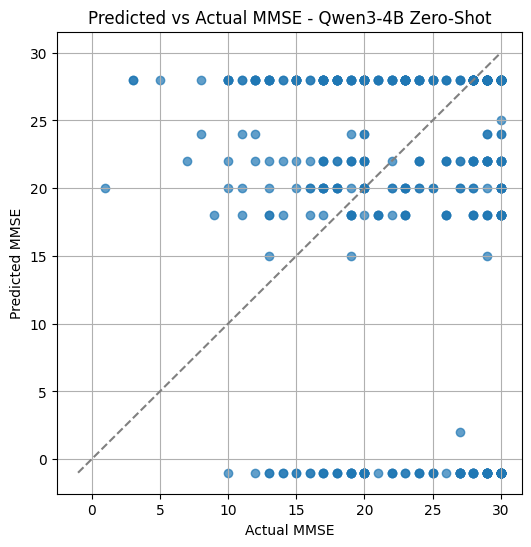

Saved MMSE scatter plot to: D:\Now\qwen3_4B_zeroshot_binaryclass_mmse_scatter.png
Saved per-class precision/recall/f1 to: D:\Now\qwen3_4B_zeroshot_binaryclass_per_class_prf.csv
Saved eval summary to: D:\Now\qwen3_4B_zeroshot_binaryclass_eval_summary.csv


In [2]:
# eval_zeroshot_vs_actual.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# ---------- Paths ----------
actual_path = r"D:\Now\2_classes.csv"
pred_path   = r"D:\Now\qwen3_4B_zeroshot_binaryclass.csv"

# ---------- Load CSVs ----------
print("Loading CSVs...")
df_true = pd.read_csv(actual_path)
df_pred = pd.read_csv(pred_path)
print("Loaded actual:", actual_path)
print("Loaded predictions:", pred_path)

# ---------- Column mapping ----------
# Actual CSV columns: id, mmse, dx (or similar)
# Prediction CSV columns: id, confidence, mmse, dx

# For actual data - use mmse and dx columns
mmse_true_col = "mmse"
label_true_col = "dx"

# For prediction data - use mmse and dx columns
mmse_pred_col = "mmse"
label_pred_col = "dx"

print(f"Using (actual) mmse column: '{mmse_true_col}'  label column: '{label_true_col}'")
print(f"Using (pred)   mmse column: '{mmse_pred_col}'  label column: '{label_pred_col}'")

# ---------- Rename for consistency ----------
df_true = df_true.rename(columns={mmse_true_col: "actual_mmse", label_true_col: "actual_label"})
df_pred = df_pred.rename(columns={mmse_pred_col: "pred_mmse", label_pred_col: "pred_label"})

# ---------- Ensure 'id' exists in both ----------
if "id" not in df_true.columns or "id" not in df_pred.columns:
    raise KeyError("Both CSVs must contain an 'id' column for matching (patient id).")

# ---------- Merge on id ----------
df_merged = pd.merge(df_pred, df_true, on="id", how="inner", suffixes=("_pred", "_true"))
if df_merged.empty:
    raise ValueError("Merge resulted in 0 rows. Check that 'id' values match between files.")

print(f"Merged {len(df_merged)} rows on 'id'.")

# ---------- Normalize label strings ----------
df_merged["pred_label_norm"] = df_merged["pred_label"].astype(str).str.strip().str.lower()
df_merged["actual_label_norm"] = df_merged["actual_label"].astype(str).str.strip().str.lower()
df_merged["label_match"] = df_merged["pred_label_norm"] == df_merged["actual_label_norm"]

# ---------- Numeric MMSE ----------
df_merged["pred_mmse"] = pd.to_numeric(df_merged["pred_mmse"], errors="coerce")
df_merged["actual_mmse"] = pd.to_numeric(df_merged["actual_mmse"], errors="coerce")
df_merged["mmse_diff"] = (df_merged["pred_mmse"] - df_merged["actual_mmse"]).abs()

# ---------- Metrics ----------
label_accuracy = df_merged["label_match"].mean() * 100
mae = df_merged["mmse_diff"].mean()
corr = df_merged["pred_mmse"].corr(df_merged["actual_mmse"])

# Optional: per-class precision/recall/f1
labels = sorted(set(df_merged["actual_label_norm"].unique()) | set(df_merged["pred_label_norm"].unique()))
y_true = df_merged["actual_label_norm"]
y_pred = df_merged["pred_label_norm"]
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)

prf_df = pd.DataFrame({
    "label": labels,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

# ---------- Print summary ----------
print("\n📊 Evaluation Results (Qwen3-4B Zero-Shot)")
print(f"Samples evaluated: {len(df_merged)}")
print(f"Label Accuracy: {label_accuracy:.2f}% ({int(df_merged['label_match'].sum())}/{len(df_merged)})")
print(f"MMSE Mean Absolute Error (MAE): {mae:.3f}")
print(f"MMSE Pearson correlation: {corr:.3f}\n")

print("Per-class precision/recall/f1:")
print(prf_df.to_string(index=False))

# ---------- Save merged CSV ----------
out_csv = r"D:\Now\qwen3_4B_zeroshot_binaryclass_vs_actual_evaluation.csv"
df_merged.to_csv(out_csv, index=False)
print(f"\nSaved merged evaluation CSV: {out_csv}")

# ---------- Confusion matrix ----------
cm = confusion_matrix(df_merged["actual_label_norm"], df_merged["pred_label_norm"], labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Qwen3-4B Zero-Shot (Binary Classification)")
confusion_path = r"D:\Now\qwen3_4B_zeroshot_binaryclass_confusion_matrix.png"
plt.savefig(confusion_path, bbox_inches="tight")
plt.show()
print(f"Saved confusion matrix to: {confusion_path}")

# ---------- Scatter plot: actual vs predicted MMSE ----------
plt.figure(figsize=(6,6))
plt.scatter(df_merged["actual_mmse"], df_merged["pred_mmse"], alpha=0.7)
xmin = min(df_merged["actual_mmse"].min(), df_merged["pred_mmse"].min())
xmax = max(df_merged["actual_mmse"].max(), df_merged["pred_mmse"].max())
plt.plot([xmin, xmax], [xmin, xmax], linestyle="--", color="gray")
plt.xlabel("Actual MMSE")
plt.ylabel("Predicted MMSE")
plt.title("Predicted vs Actual MMSE - Qwen3-4B Zero-Shot")
plt.grid(True)
scatter_path = r"D:\Now\qwen3_4B_zeroshot_binaryclass_mmse_scatter.png"
plt.savefig(scatter_path, bbox_inches="tight")
plt.show()
print(f"Saved MMSE scatter plot to: {scatter_path}")

# ---------- Save per-class PRF ----------
prf_out = r"D:\Now\qwen3_4B_zeroshot_binaryclass_per_class_prf.csv"
prf_df.to_csv(prf_out, index=False)
print(f"Saved per-class precision/recall/f1 to: {prf_out}")

# ---------- Small summary file ----------
summary = {
    "n_samples": [len(df_merged)],
    "label_accuracy_pct": [label_accuracy],
    "mmse_mae": [mae],
    "mmse_corr": [corr]
}
pd.DataFrame(summary).to_csv(r"D:\Now\qwen3_4B_zeroshot_binaryclass_eval_summary.csv", index=False)
print(r"Saved eval summary to: D:\Now\qwen3_4B_zeroshot_binaryclass_eval_summary.csv")

In [ ]:
# ---------- Overall Precision, Recall, F1 ----------
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Load merged evaluation CSV to get y_true and y_pred
merged_csv = r"E:\Thesis\gpt_oss_zeroshot_binaryclass_vs_actual_evaluation.csv"
df_merged = pd.read_csv(merged_csv)

# Use normalized label columns if available, else fallback
if 'actual_label_norm' in df_merged.columns and 'pred_label_norm' in df_merged.columns:
    y_true = df_merged['actual_label_norm']
    y_pred = df_merged['pred_label_norm']
else:
    y_true = df_merged['actual_label']
    y_pred = df_merged['pred_label']

macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f"\nOverall Macro Precision: {macro_precision:.3f}")
print(f"Overall Macro Recall:    {macro_recall:.3f}")
print(f"Overall Macro F1 Score:  {macro_f1:.3f}")


In [ ]:
# DEBUG: Inspect raw responses to understand model output pattern
import pandas as pd

# Load the results CSV
results_df = pd.read_csv(r"D:\Now\qwen3_4B_zeroshot_binaryclass.csv")

# Check distribution
print("Label distribution:")
print(results_df['dx'].value_counts())
print("\nControl labels with valid MMSE:")
print(results_df[results_df['dx'] == 'Control']['mmse'].value_counts())
print("\nProbableAD labels with valid MMSE:")
print(results_df[results_df['dx'] == 'ProbableAD']['mmse'].value_counts())

# Show statistics
print("\n" + "="*60)
print("MMSE Statistics by Label:")
print("="*60)
for label in ['Control', 'ProbableAD', 'Unknown']:
    subset = results_df[results_df['dx'] == label]['mmse']
    valid = subset[subset >= 0]
    print(f"\n{label}:")
    print(f"  Total predictions: {len(subset)}")
    print(f"  Valid MMSE (>=0): {len(valid)}")
    print(f"  Invalid MMSE (-1): {len(subset[subset < 0])}")
    if len(valid) > 0:
        print(f"  Valid MMSE range: {valid.min()}-{valid.max()}")
        print(f"  Valid MMSE mean: {valid.mean():.1f}")